# Jigsaw toxic comment classification with an LSTM

This notebook explores the Jigsaw dataset, prepares text sequences, compares weighted and unweighted BCE with an Embedding + LSTM model, and evaluates the selected model on a held-out test set.

Training is implemented in `src/toxic_lstm.py`. The notebook loads saved results by default. Set `RUN_TRAINING = True` to train both configurations again.

The six labels are toxic, severe_toxic, obscene, threat, insult and identity_hate. A comment can have several labels, so the model uses sigmoid probabilities and binary cross-entropy.


In [1]:
from pathlib import Path
import sys, json, inspect, hashlib
import numpy as np
import pandas as pd
import torch
from IPython.display import display, Image

cwd = Path.cwd()
candidates = [cwd, cwd.parent, cwd / "task2", cwd.parent / "task2"]
ROOT = next((p for p in candidates if (p / "src/toxic_lstm.py").exists()), None)
if ROOT is None:
    raise FileNotFoundError("Open the notebook from the task2 directory or its notebooks directory.")
sys.path.insert(0, str(ROOT / "src"))
from toxic_lstm import (LABELS, Config, clean_text, tokenize, build_vocabulary, encode,
                        collate_batch, ToxicLSTM, metric_report, predict_texts, run,
                        seed_everything, tune_thresholds)
RESULTS = ROOT / "results"
RUN_TRAINING = False
if RUN_TRAINING:
    run(ROOT / "data/raw/train.csv", Config())
summary = json.loads((RESULTS / "run_summary.json").read_text())
config = Config(**summary["config"])
seed_everything(config.seed, config.threads)
print("Recorded execution:", summary["device"], "PyTorch", summary["torch_version"])
print("Current environment:", torch.__version__)
display(pd.Series(summary["config"], name="configuration"))

Recorded execution: cpu PyTorch 2.14.1+cpu
Current environment: 2.14.1+cpu


seed                42.0000
vocab_size       30000.0000
min_frequency        2.0000
max_length         128.0000
embedding_dim       64.0000
hidden_size         64.0000
dropout              0.3000
batch_size         256.0000
epochs               6.0000
patience             2.0000
learning_rate        0.0020
weight_decay         0.0001
clip_norm            1.0000
threads              4.0000
Name: configuration, dtype: float64

## 1 Data loading and validation

Use the original `train.csv` for all three local splits. The competition test file is not used as our labeled holdout. Validate the schema and binary targets before modeling.

In [2]:
raw = pd.read_csv(ROOT / "data/raw/train.csv")
assert len(raw) == 159571
assert set(["id", "comment_text"] + LABELS).issubset(raw.columns)
assert np.isin(raw[LABELS].to_numpy(), [0, 1]).all()
assert not raw[LABELS].isna().any().any()
digest = hashlib.sha256((ROOT / "data/raw/train.csv").read_bytes()).hexdigest()
assert digest == summary["data"]["source_csv_sha256"]
print("Shape:", raw.shape)
display(raw.isna().sum().to_frame("missing_values"))
display(raw.head(3))

Shape: (159571, 8)


,missing_values
id,0
comment_text,0
toxic,0
severe_toxic,0
obscene,0
threat,0
insult,0
identity_hate,0


,id,comment_text,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,0000997932d777bf,Explanation\nWhy the edits made under my usern...,0,0,0,0,0,0
1,000103f0d9cfb60f,D'aww! He matches this background colour I'm s...,0,0,0,0,0,0
2,000113f07ec002fd,"Hey man, I'm really not trying to edit war. It...",0,0,0,0,0,0


## 2 Exploration and label imbalance

The labels are independent binary decisions but statistically correlated. A comment may carry multiple labels. An all-zero vector means none of the six toxicity labels is annotated. Counts and co-occurrence reveal why accuracy alone is inadequate.

,positive_count,positive_fraction
toxic,15294,0.095844
severe_toxic,1595,0.009996
obscene,8449,0.052948
threat,478,0.002996
insult,7877,0.049364
identity_hate,1405,0.008805


No positive labels: 0.8983211235124177
Multiple positive labels: 0.06182201026502309


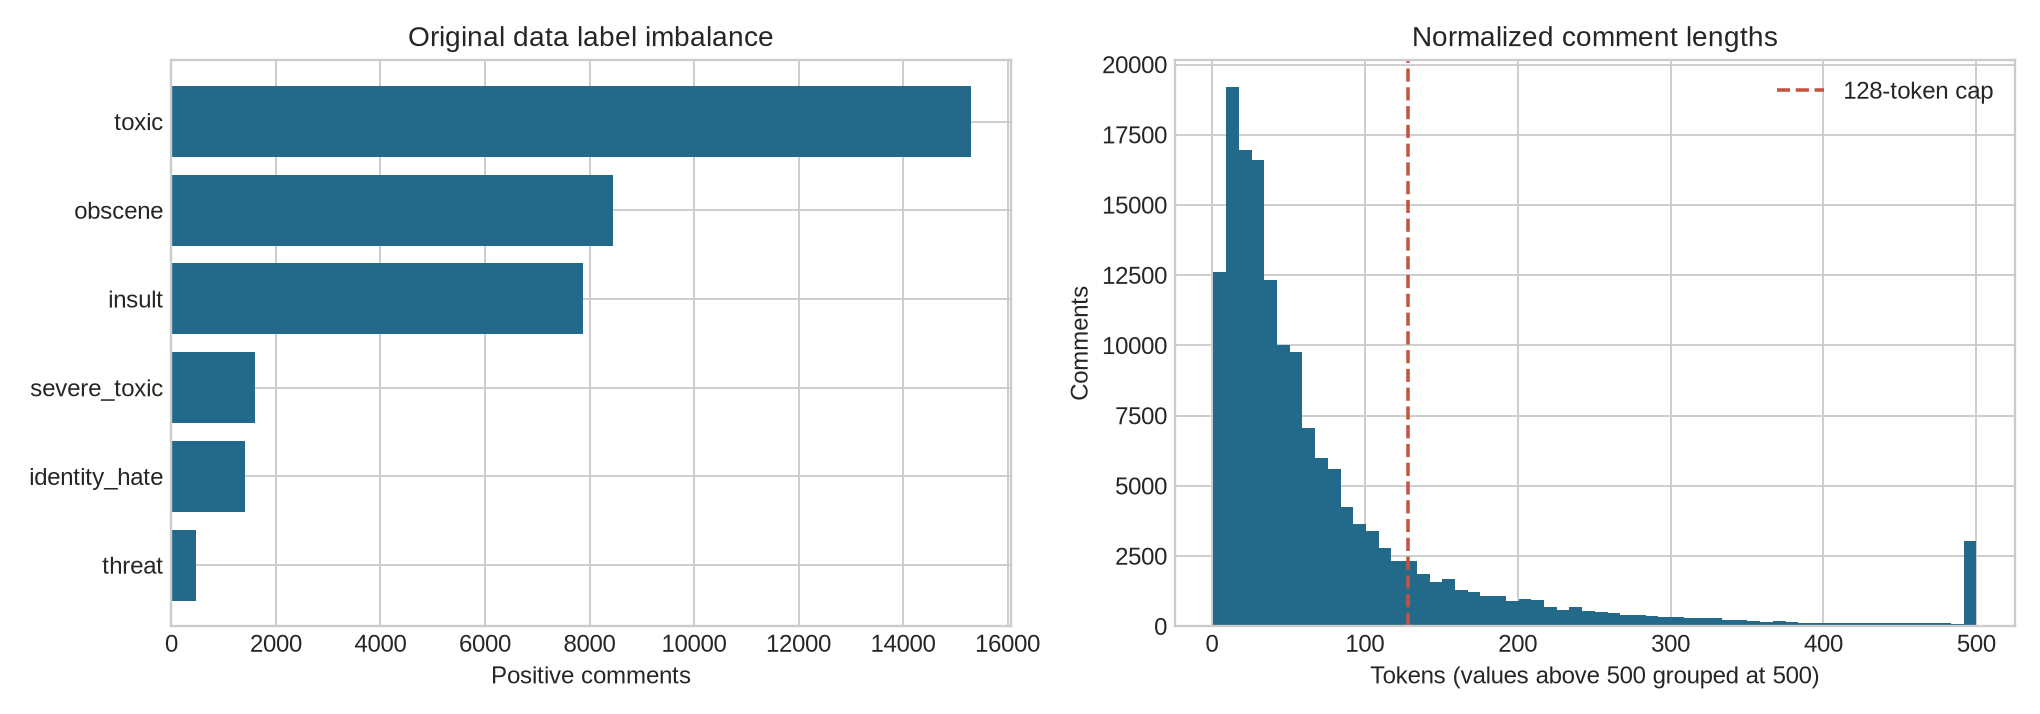

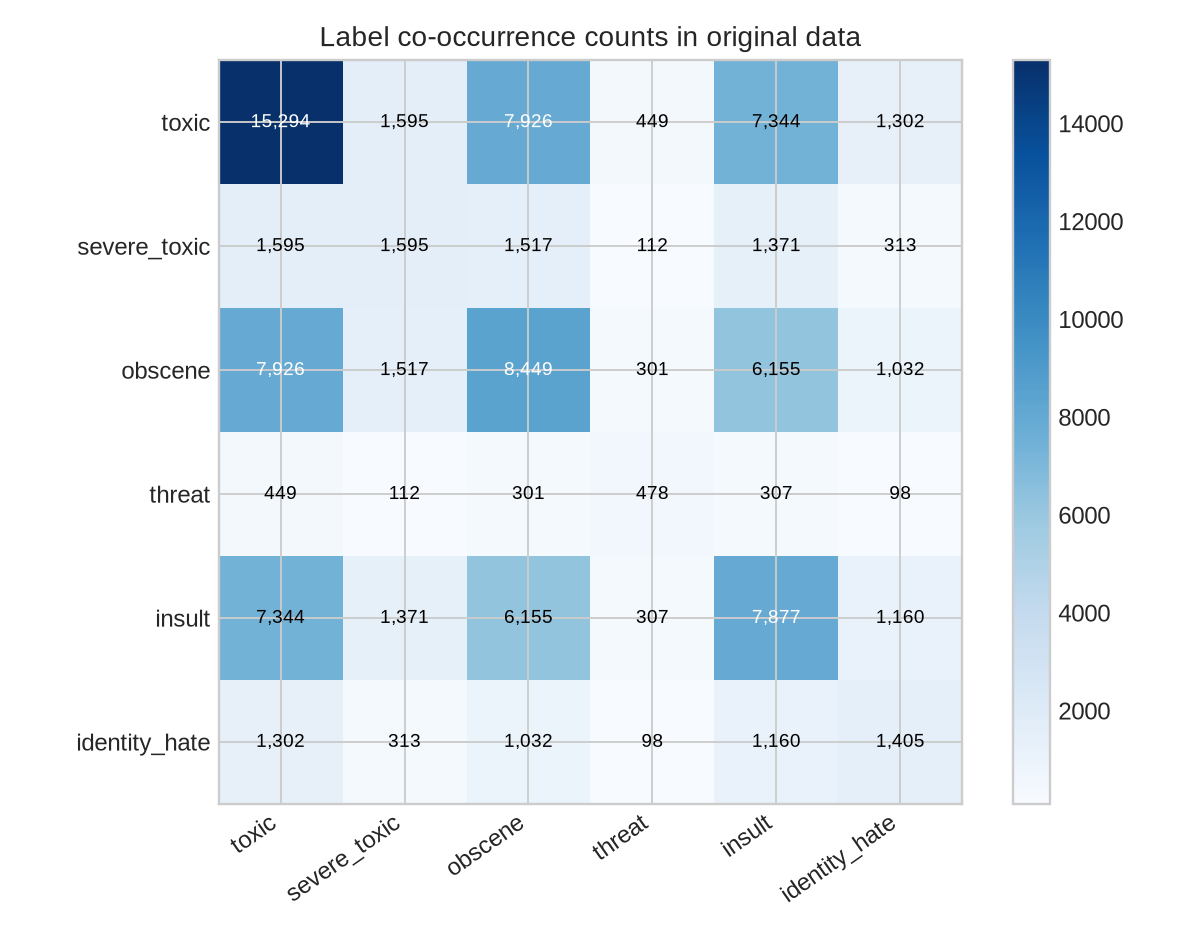

In [3]:
label_counts = raw[LABELS].sum()
display(pd.DataFrame({"positive_count": label_counts, "positive_fraction": label_counts / len(raw)}))
print("No positive labels:", (raw[LABELS].sum(axis=1) == 0).mean())
print("Multiple positive labels:", (raw[LABELS].sum(axis=1) > 1).mean())
display(Image(filename=str(RESULTS / "eda_overview.png")))
display(Image(filename=str(RESULTS / "label_cooccurrence.png")))

## 3 Conservative cleaning and tokenization

Normalize case and whitespace, unescape HTML, and replace URLs/mentions with placeholders. Preserve negation, contractions and punctuation. Do not remove stopwords or stem words: the sequential model needs meaningful context.

Normalized-identical comments are collapsed **before splitting** to prevent identical inputs appearing in train and test. Conflicting annotations are combined by taking the union of positive labels. This is a documented tradeoff that can retain disputed positives; it is not an assertion that every annotation is correct.

In [4]:
print(inspect.getsource(clean_text))
example = "I am NOT angry! See https://example.org &amp; ask @Editor."
cleaned = clean_text(example)
print("Cleaned:", cleaned)
print("Tokens:", tokenize(cleaned))
print("Duplicate policy:", summary["data"]["duplicate_policy"])
print("Normalized repeats collapsed:", summary["data"]["normalized_duplicates_collapsed"])
print("Conflicting groups:", summary["data"]["conflicting_normalized_groups"])

def clean_text(text: str) -> str:
    """Conservative normalization: keep negation, profanity and punctuation."""
    text = html.unescape(str(text)).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " <url> ", text)
    text = re.sub(r"(?<!\w)@[a-z0-9_]+", " <user> ", text)
    return re.sub(r"\s+", " ", text).strip()

Cleaned: i am not angry! see <url> & ask <user> .
Tokens: ['i', 'am', 'not', 'angry', '!', 'see', '<url>', '&', 'ask', '<user>', '.']
Duplicate policy: Collapse normalized identical comments; union positive labels; retain first ID/text.
Normalized repeats collapsed: 273
Conflicting groups: 41


In [5]:
data = raw.copy()
data["clean_text"] = data.comment_text.fillna("").map(clean_text)
data = data.loc[data.clean_text != ""].copy()
data = data.groupby("clean_text", sort=False, as_index=False).agg(
    {"id": "first", "comment_text": "first", **{label: "max" for label in LABELS}})
assignments = pd.read_csv(RESULTS / "split_assignments.csv", dtype={"id": str})
data = data.merge(assignments[["id", "split"]], on="id", validate="one_to_one")
assert len(data) == summary["data"]["usable_rows"]
assert data["split"].notna().all()
data["tokens"] = data.clean_text.map(tokenize)
data["token_length"] = data.tokens.map(len)
print("Usable unique normalized comments:", len(data))

Usable unique normalized comments: 159298


## 4 Train validation and test split

The training script uses two `MultilabelStratifiedShuffleSplit` operations, first an 80/20 split and then a 50/50 split of the holdout. The resulting local split is approximately 80/10/10. Stratification preserves label marginals, not every possible label combination.

Only training fits the vocabulary, weights and parameters. Validation chooses the best epoch, loss configuration and per-label thresholds. Test remains held out until those choices are frozen. Normalized duplicate groups are collapsed before any split; near-duplicate paraphrases are not detected.

toxic           severe_toxic           obscene           threat  \
              sum      mean          sum      mean     sum      mean    sum   
split                                                                         
test         1525  0.095731          159  0.009981     843  0.052919     48   
train       12204  0.095764         1274  0.009997    6742  0.052904    381   
validation   1526  0.095794          159  0.009981     842  0.052856     47   

                     insult           identity_hate            
                mean    sum      mean           sum      mean  
split                                                          
test        0.003013    786  0.049341           140  0.008788  
train       0.002990   6286  0.049326          1120  0.008789  
validation  0.002950    786  0.049341           140  0.008788

Normalized-text overlap across splits: zero


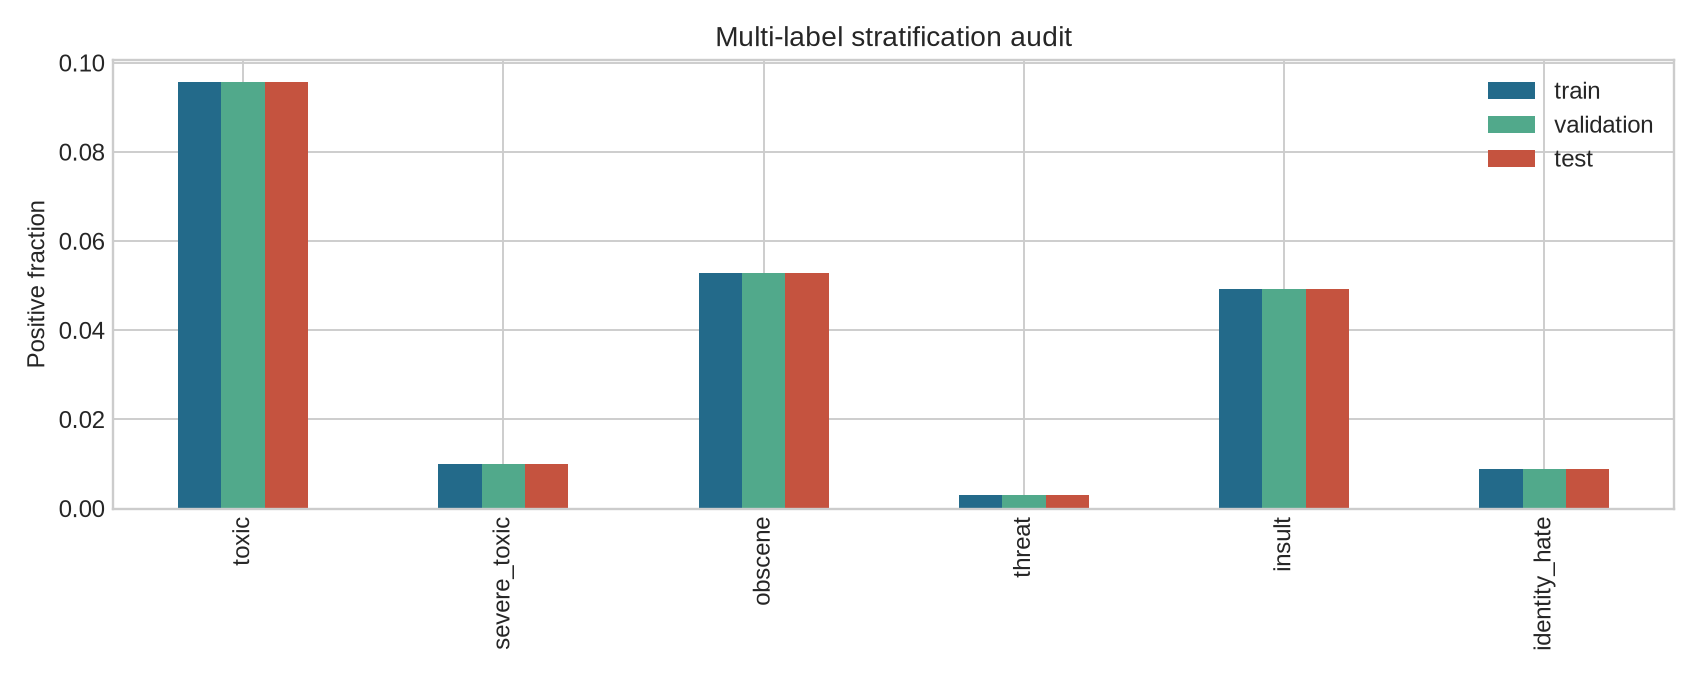

In [6]:
display(data.groupby("split")[LABELS].agg(["sum", "mean"]))
sets = {name: set(data.loc[data.split == name, "clean_text"]) for name in ["train", "validation", "test"]}
assert not sets["train"] & sets["validation"]
assert not sets["train"] & sets["test"]
assert not sets["validation"] & sets["test"]
print("Normalized-text overlap across splits: zero")
display(Image(filename=str(RESULTS / "split_prevalence.png")))

## 5 Vocabulary sequences and dynamic padding

The vocabulary contains up to 30,000 tokens with minimum training frequency 2. PAD is 0, UNK is 1. The first 128 tokens are retained, and padding is applied only to the longest sequence in the batch. The model gathers the final **real-token** output, so later right-padding cannot change the classification in this unidirectional LSTM.

In [7]:
vocab = json.loads((RESULTS / "vocabulary.json").read_text())
rebuilt = build_vocabulary(data.loc[data.split == "train", "tokens"], config.vocab_size, config.min_frequency)
assert rebuilt == vocab, "Saved vocabulary must match train-only fitting."
print("Vocabulary size:", len(vocab))
display(pd.Series(summary["data"]["train_token_length_quantiles"], name="training_length_quantiles"))
display(pd.DataFrame({"truncated_fraction": summary["data"]["truncated_fraction"],
                      "unknown_token_fraction": summary["data"]["oov_token_fraction"]}))
texts = ["I disagree with your argument.", "Thank you!"]
sequences = [encode(tokenize(clean_text(t)), vocab, config.max_length) for t in texts]
batch = [(torch.tensor(s), torch.zeros(6)) for s in sequences]
tokens, lengths, targets = collate_batch(batch)
print("IDs:\n", tokens, "\nReal lengths:", lengths)
print("Shapes:", tuple(tokens.shape), tuple(targets.shape))

Vocabulary size: 30000


0.5      44.00
0.9     183.00
0.95    277.00
0.99    705.63
Name: training_length_quantiles, dtype: float64

,truncated_fraction,unknown_token_fraction
train,0.163962,0.021547
validation,0.162021,0.026866
test,0.159448,0.025261


IDs:
 tensor([[ 11, 796,  31,  30, 649,   2],
        [143,  10,  16,   0,   0,   0]]) 
Real lengths: tensor([6, 3])
Shapes: (2, 6) (2, 6)


## 6 Model architecture

`Embedding(30000,64) → LSTM(64,64) → Dropout(0.3) → Linear(64,6)`.

The LSTM uses sigmoid input/forget/output gates and a tanh candidate cell. It retains sequential information but compresses each comment into one final hidden state. Gate-aware initialization uses Xavier input matrices, orthogonal recurrent matrices and an effective forget bias of one. Six logits support simultaneous positives; sigmoid is used at evaluation.

In [8]:
checkpoint = torch.load(ROOT / "models/selected_model.pt", map_location="cpu", weights_only=False)
assert checkpoint["labels"] == LABELS
model = ToxicLSTM(len(vocab), config.embedding_dim, config.hidden_size, config.dropout)
model.load_state_dict(checkpoint["model_state"])
model.eval()
print(model)
print("Trainable parameters:", sum(p.numel() for p in model.parameters()))
print(inspect.getsource(ToxicLSTM.forward))
with torch.no_grad():
    logits = model(tokens, lengths)
    probabilities = torch.sigmoid(logits)
print("Logit/probability shape:", tuple(logits.shape), tuple(probabilities.shape))
print("Probabilities need not sum to one:", probabilities.sum(dim=1))

ToxicLSTM(
  (embedding): Embedding(30000, 64, padding_idx=0)
  (lstm): LSTM(64, 64, batch_first=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (classifier): Linear(in_features=64, out_features=6, bias=True)
)
Trainable parameters: 1953670
    def forward(self, tokens, lengths):
        output, _ = self.lstm(self.embedding(tokens))
        last_real = output[torch.arange(output.size(0), device=output.device), lengths.to(output.device) - 1]
        return self.classifier(self.dropout(last_real))  # Six logits, no sigmoid during BCE training.

Logit/probability shape: (2, 6) (2, 6)
Probabilities need not sum to one: tensor([0.0912, 0.1672])


## 7 Binary cross entropy and class weights

For label $c$, the weighted loss is

$$-q_c y_c\log\sigma(z_c)-(1-y_c)\log(1-\sigma(z_c)).$$

The unweighted experiment sets $q_c=1$. The weighted experiment sets $q_c=N_{negative,c}/N_{positive,c}$ using train only. `BCEWithLogitsLoss` accepts raw logits and applies sigmoid internally for numerical stability; do not sigmoid twice. Large positive weights can increase recall and false positives. Focal loss is an alternative for a future comparison, not an executed experiment here.

In [9]:
train_y = data.loc[data.split == "train", LABELS].to_numpy(dtype=np.float32)
positives = train_y.sum(axis=0)
positive_weights = (len(train_y) - positives) / positives
assert np.allclose(positive_weights, checkpoint["positive_weights"])
display(pd.Series(positive_weights, index=LABELS, name="train_only_positive_weight"))
plain_loss = torch.nn.BCEWithLogitsLoss()
weighted_loss = torch.nn.BCEWithLogitsLoss(pos_weight=torch.tensor(positive_weights))
print("BCE example, six positives:", plain_loss(torch.zeros((1,6)), torch.ones((1,6))).item())

toxic              9.442314
severe_toxic      99.029831
obscene           17.902105
threat           333.482941
insult            19.273306
identity_hate    112.783928
Name: train_only_positive_weight, dtype: float32

BCE example, six positives: 0.6931471824645996


## 8 Training and overfitting monitoring

Both configurations trained from the same initialization seed for at most six epochs, using AdamW, gradient clipping, a plateau scheduler and early stopping. The best checkpoint maximizes validation macro average precision. The training source below is the exact implementation that generated the saved logs; the executed notebook defaults to loading those logs rather than repeating the run.

Loss values have different scales between weighted and unweighted training. Compare curves within a configuration. Falling train loss alongside rising validation loss is a warning about generalization/calibration, even if ranking metrics still improve.

In [10]:
from toxic_lstm import train_experiment
print(inspect.getsource(train_experiment))

def train_experiment(name, config, sequences, y, indices, vocab, output, device):
    seed_everything(config.seed, config.threads)
    train_loader = make_loader(sequences, y, indices["train"], config, shuffle=True)
    validation_loader = make_loader(sequences, y, indices["validation"], config)
    model = ToxicLSTM(len(vocab), config.embedding_dim, config.hidden_size, config.dropout).to(device)
    positives = y[indices["train"]].sum(axis=0)
    weights = (len(indices["train"]) - positives) / np.maximum(positives, 1)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(weights, dtype=torch.float32, device=device)
                                    if name == "weighted_bce" else None)
    optimizer = torch.optim.AdamW(model.parameters(), lr=config.learning_rate, weight_decay=config.weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=1, factor=0.5)
    best_score = -1.0; stale = 0; history = []; best_epoch = 0
    experiment

unweighted_bce best epoch 5


,epoch,train_loss,validation_loss,validation_macro_ap,validation_macro_f1_at_05,validation_micro_f1_at_05,gradient_norm_mean_before_clip,learning_rate,elapsed_seconds
0,1,0.093695,0.053939,0.480308,0.383357,0.720072,0.195826,0.002,29.743776
1,2,0.051546,0.050190,0.520684,0.375785,0.704590,0.123639,0.002,27.136779
2,3,0.045375,0.049078,0.525090,0.386556,0.729809,0.068408,0.002,28.452085
3,4,0.041062,0.053980,0.524928,0.433017,0.710924,0.058478,0.002,27.589161
4,5,0.036585,0.054087,0.538385,0.431018,0.731817,0.052632,0.002,28.287533
5,6,0.033153,0.055955,0.538262,0.465025,0.720183,0.054276,0.002,27.424643


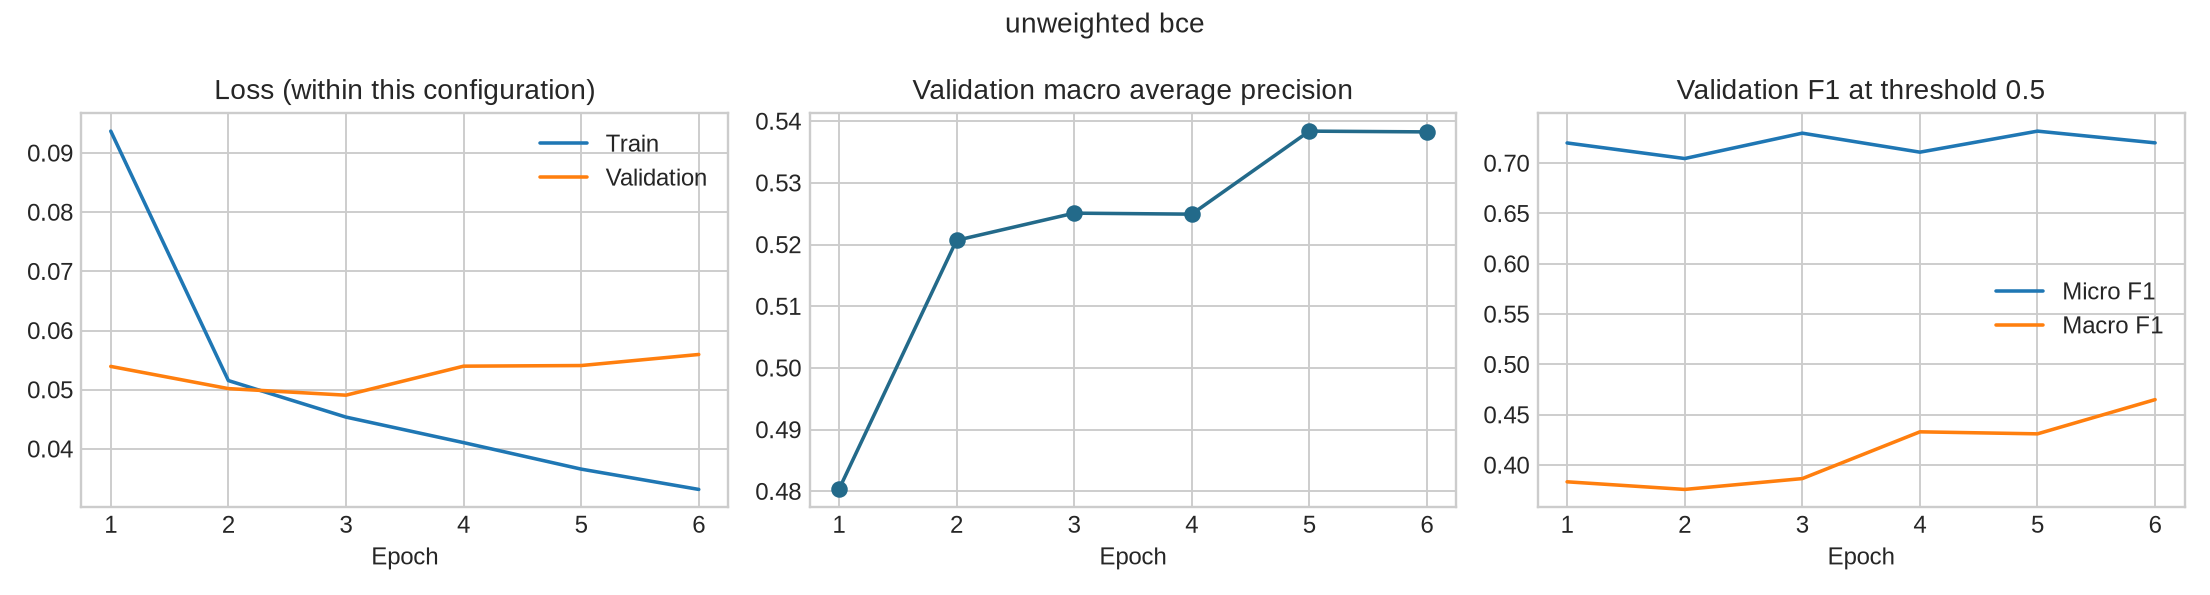

weighted_bce best epoch 4


,epoch,train_loss,validation_loss,validation_macro_ap,validation_macro_f1_at_05,validation_micro_f1_at_05,gradient_norm_mean_before_clip,learning_rate,elapsed_seconds
0,1,0.584353,0.405258,0.492025,0.380768,0.456462,1.504241,0.002,27.330528
1,2,0.337211,0.411454,0.515752,0.415403,0.511620,0.767381,0.002,27.608376
2,3,0.264317,0.485289,0.552530,0.423511,0.536683,0.799486,0.002,25.358723
3,4,0.212804,0.561304,0.553652,0.454088,0.584247,0.503550,0.002,30.822149
4,5,0.174960,0.616668,0.544291,0.446237,0.573845,0.450515,0.002,29.862069
5,6,0.149432,0.761484,0.540544,0.469938,0.603543,0.366975,0.002,28.761532


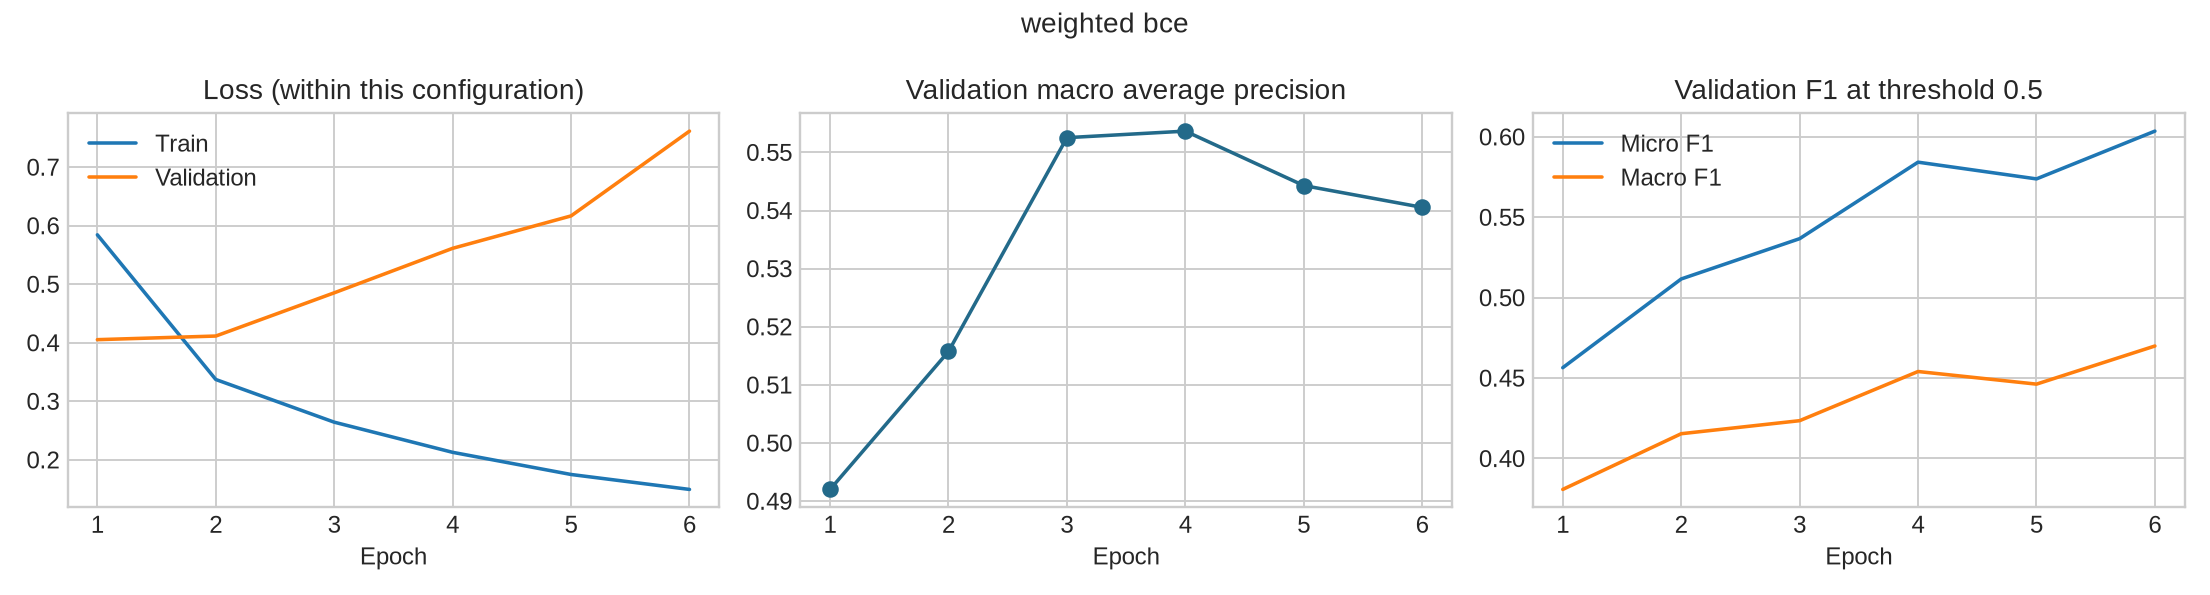

In [11]:
experiments = json.loads((RESULTS / "experiment_comparison.json").read_text())
for experiment in experiments:
    name = experiment["experiment"]
    print(name, "best epoch", experiment["best_epoch"])
    display(pd.read_csv(RESULTS / name / "history.csv"))
    display(Image(filename=str(RESULTS / name / "training_curves.png")))

## 9 Validation selection and frozen thresholds

Select the loss configuration by the highest validation macro AP. For its best checkpoint, tune each label's threshold on validation using a grid from 0.05 to 0.95 to maximize F1, with ties closest to 0.5. Threshold tuning makes validation F1 optimistic; test estimates the frozen pipeline independently.

Average precision (AP) is a stepwise precision-recall summary; **PR-AUC here means trapezoidal area under the precision-recall curve**. Both are saved, and AP is the checkpoint/selection metric.

In [12]:
columns = ["experiment", "best_epoch", "validation_macro_ap", "validation_macro_pr_auc",
           "validation_macro_f1_at_05", "validation_macro_f1_tuned", "validation_micro_f1_tuned"]
display(pd.DataFrame(experiments)[columns])
selected = max(experiments, key=lambda row: row["validation_macro_ap"])
assert selected["experiment"] == summary["selected_experiment"]
print("Selected:", selected["experiment"])
validation = np.load(RESULTS / selected["experiment"] / "validation_predictions.npz")
assert np.allclose(tune_thresholds(validation["y_true"], validation["probabilities"]), checkpoint["thresholds"])
display(pd.Series(checkpoint["thresholds"], index=LABELS, name="validation_tuned_threshold"))

,experiment,best_epoch,validation_macro_ap,validation_macro_pr_auc,validation_macro_f1_at_05,validation_macro_f1_tuned,validation_micro_f1_tuned
0,unweighted_bce,5,0.538385,0.534571,0.431018,0.542651,0.717066
1,weighted_bce,4,0.553652,0.551198,0.454088,0.559201,0.710530


Selected: weighted_bce


toxic            0.82
severe_toxic     0.95
obscene          0.93
threat           0.95
insult           0.88
identity_hate    0.95
Name: validation_tuned_threshold, dtype: float64

## 10 Held-out evaluation

Report precision, recall, F1, ROC-AUC and PR-AUC for every label. Micro F1 pools all decisions, while macro F1 gives equal weight to every label. Exact-match accuracy is also included but can look high because most comments have no positive labels. AUC scores use probabilities and are threshold-independent.

,precision,recall,f1,support,roc_auc,pr_auc,average_precision
label,,,,,,,
toxic,0.794976,0.767869,0.781187,1525,0.961713,0.854187,0.854220
severe_toxic,0.341808,0.761006,0.471735,159,0.989176,0.409631,0.412635
obscene,0.795508,0.798339,0.796921,843,0.987513,0.875558,0.875624
threat,0.214286,0.687500,0.326733,48,0.982938,0.317849,0.331892
insult,0.626008,0.790076,0.698538,786,0.977787,0.749534,0.749763
identity_hate,0.260417,0.535714,0.350467,140,0.968166,0.245041,0.250101


,fixed_0.5,validation_tuned
micro_f1,0.585380,0.708202
macro_f1,0.461278,0.570930
macro_precision,0.346983,0.505500
macro_recall,0.896143,0.723418
macro_roc_auc,0.977882,0.977882
macro_pr_auc,0.575300,0.575300
macro_average_precision,0.579039,0.579039
subset_accuracy,0.866164,0.907470
hamming_loss,0.046286,0.023227


All-negative baseline: exact-match accuracy 0.8981167608286252 ; micro F1 = 0; macro F1 = 0


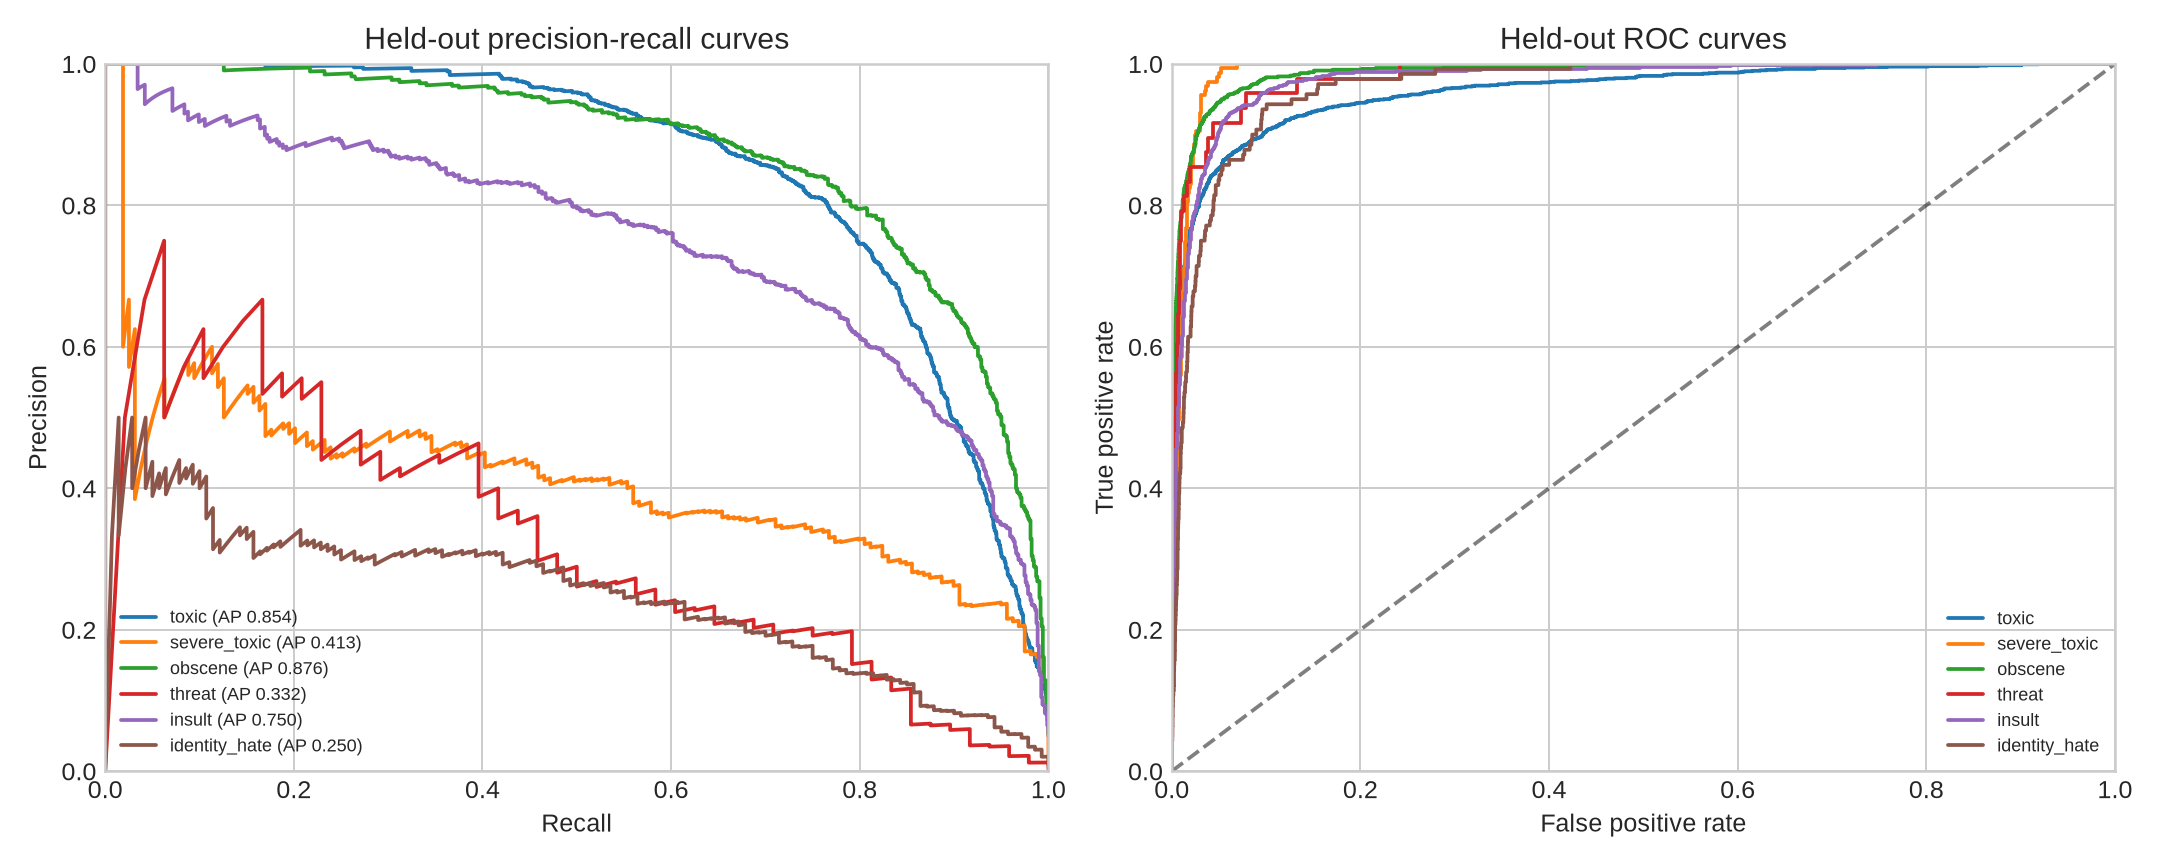

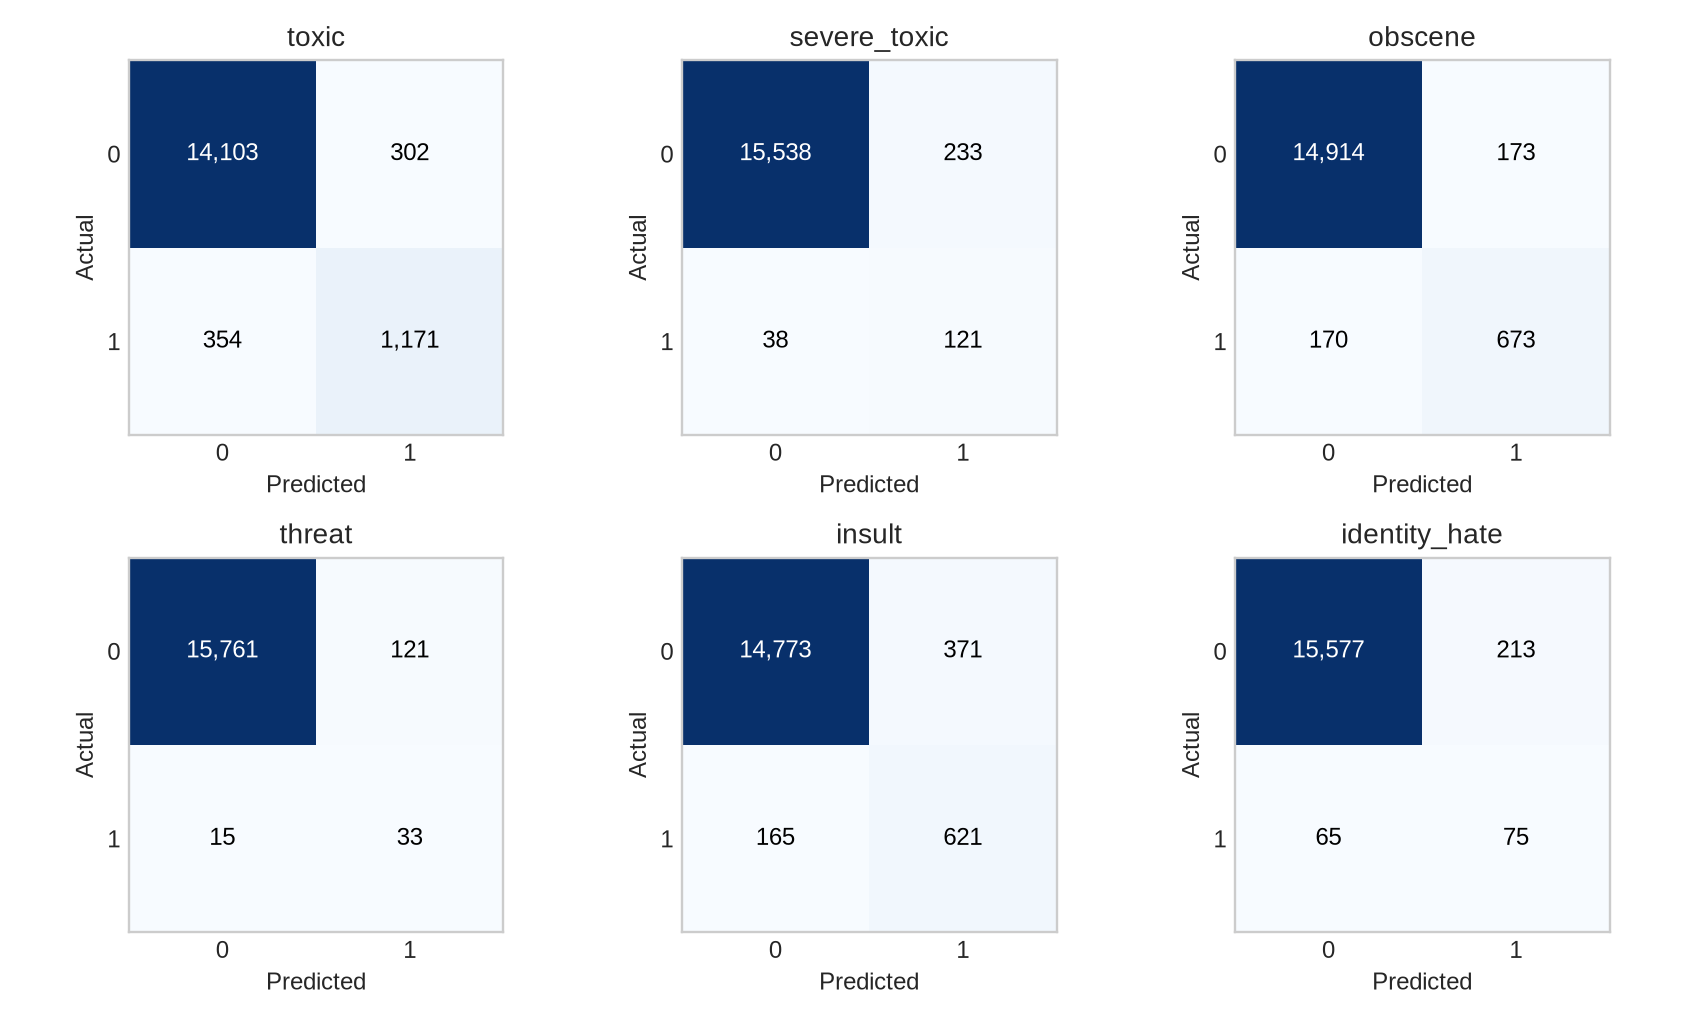

In [13]:
test_predictions = np.load(RESULTS / "test_predictions.npz")
y_test = test_predictions["y_true"]
p_test = test_predictions["probabilities"]
thresholds = test_predictions["thresholds"]
test_tuned = metric_report(y_test, p_test, thresholds)
test_at_05 = metric_report(y_test, p_test, .5)
assert np.isclose(test_tuned["micro_f1"], summary["test_tuned"]["micro_f1"])
assert set(test_predictions["ids"]) == set(data.loc[data.split == "test", "id"])
display(pd.DataFrame(test_tuned["per_label"]).set_index("label"))
metric_names = ["micro_f1", "macro_f1", "macro_precision", "macro_recall", "macro_roc_auc",
                "macro_pr_auc", "macro_average_precision", "subset_accuracy", "hamming_loss"]
display(pd.DataFrame({"fixed_0.5": {k:test_at_05[k] for k in metric_names},
                      "validation_tuned": {k:test_tuned[k] for k in metric_names}}))
print("All-negative baseline: exact-match accuracy", float((y_test.sum(axis=1) == 0).mean()),
      "; micro F1 = 0; macro F1 = 0")
display(Image(filename=str(RESULTS / "test_pr_roc_curves.png")))
display(Image(filename=str(RESULTS / "test_confusion_matrices.png")))

## 11 Error analysis

Inspect confident false positives and false negatives rather than relying on one aggregate score. Error examples include the original token length and whether the 128-token cap discarded a suffix. Annotation disagreement, quoted toxic language, misspellings and implicit threats are possible mechanisms to examine; a score alone does not establish the cause of an error.

In [14]:
errors = pd.read_csv(RESULTS / "error_examples.csv")
display(errors.groupby(["label", "error_type"]).size().unstack(fill_value=0))
display(errors.groupby(["label", "error_type"], sort=False).head(1))
display(pd.Series(json.loads((RESULTS / "error_summary.json").read_text()), name="error_summary"))

error_type,false_negative,false_positive
label,,
identity_hate,5,5
insult,5,5
obscene,5,5
severe_toxic,5,5
threat,5,5
toxic,5,5


,id,label,error_type,probability,threshold,original_tokens,was_truncated,comment_excerpt
0,14687ee2dc4bbfb7,toxic,false_positive,0.997832,0.82,246,True,"""\n\n My Statement \n\nOh wow, I take a little..."
5,1fe86ef8577c7cb7,toxic,false_negative,0.001346,0.82,15,False,Your not a scholar and you should be banned fo...
10,0109d5a4788850f7,severe_toxic,false_positive,0.996208,0.95,144,True,Thank you for your RACIST experimenting with t...
15,f036e1e0139fc31e,severe_toxic,false_negative,0.063814,0.95,24,False,"That's fucken offensive, you scumbag, wishing ..."
20,8cdbf38e4ef0e23a,obscene,false_positive,0.998431,0.93,84,False,Dog -n- Suds article \n\nI'm sorry for coming ...
25,99e7fbef712fd454,obscene,false_negative,0.001723,0.93,158,True,Prediction Timetable is getting bloated \n\nWh...
30,c386e1844b1a5387,threat,false_positive,0.999257,0.95,55,False,Wow. \n\nOmg okay so i just made this really l...
35,ca01041f4db5125e,threat,false_negative,0.002283,0.95,9,False,I wish you had died in that earthquake.
40,96f362c0edfc69d7,insult,false_positive,0.996452,0.88,8,False,Text Edit\n\nFuck. Shit. Cunt.
45,99e7fbef712fd454,insult,false_negative,0.001197,0.88,158,True,Prediction Timetable is getting bloated \n\nWh...


samples_with_any_error           1474.000000
total_test_samples              15930.000000
error_fraction_truncated            0.065748
error_fraction_not_truncated        0.097610
Name: error_summary, dtype: float64

## 12 Results and limitations

The selected configuration is **weighted_bce**. Its held-out micro F1 is **0.7082**, macro F1 **0.5709**, macro ROC-AUC **0.9779**, and macro PR-AUC **0.5753**.

Strengths are joint embedding learning, sensitivity to word order, independent multi-label outputs, and reproducible CPU execution. Limitations include one seed, rare-label uncertainty, word-level unknown tokens, prefix truncation, a single final-state representation and domain shift beyond English Wikipedia. Identity-term subgroup fairness was not measured. The results are local held-out estimates, not competition leaderboard results.

Possible future experiments: repeat seeds, compare a TF-IDF baseline, use pretrained embeddings, extend sequence length, pool LSTM outputs or use a bidirectional model, and compare a transformer with the same validation protocol. These are proposed improvements, not completed experiments.

## 13 Inference on new text

The checkpoint stores the vocabulary, architecture settings, label order and frozen thresholds. The following outputs are actual model predictions, not asserted ground-truth labels.

In [15]:
examples = ["Thank you for improving this article.",
            "I disagree with your argument, but we can discuss it.",
            "You are an idiot and your edits are garbage."]
scores, decisions = predict_texts(examples)
scores.insert(0, "comment", examples)
display(scores)
display(pd.DataFrame(decisions, columns=LABELS, index=range(len(examples))))

,comment,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,Thank you for improving this article.,0.002166,0.000189,0.001090,0.000320,0.000956,0.000165
1,"I disagree with your argument, but we can disc...",0.003031,0.000176,0.001236,0.000321,0.001211,0.000177
2,You are an idiot and your edits are garbage.,0.994803,0.692109,0.991278,0.056580,0.982647,0.623689


,toxic,severe_toxic,obscene,threat,insult,identity_hate
0,False,False,False,False,False,False
1,False,False,False,False,False,False
2,True,False,True,False,True,False


## 14 Model checks

The supplied tests verify right-padding invariance, train-vocabulary unknown handling with preserved negation, independent positive outputs and finite BCE gradients, and threshold recovery on a controlled separable example.

In [16]:
import unittest
import test_pipeline
suite = unittest.defaultTestLoader.loadTestsFromModule(test_pipeline)
result = unittest.TextTestRunner(verbosity=2).run(suite)
assert result.wasSuccessful()

test_extra_right_padding_cannot_change_prediction (test_pipeline.PipelineTests.test_extra_right_padding_cannot_change_prediction) ... 

ok


test_six_labels_can_be_positive_simultaneously_and_loss_is_finite (test_pipeline.PipelineTests.test_six_labels_can_be_positive_simultaneously_and_loss_is_finite) ... 

ok


test_thresholds_recover_separable_low_probability_labels (test_pipeline.PipelineTests.test_thresholds_recover_separable_low_probability_labels) ... 

ok


test_train_vocabulary_does_not_admit_unseen_validation_word (test_pipeline.PipelineTests.test_train_vocabulary_does_not_admit_unseen_validation_word) ... 

ok


----------------------------------------------------------------------
Ran 4 tests in 0.565s

OK


References:

1. [Jigsaw dataset specified in the task](https://www.kaggle.com/datasets/julian3833/jigsaw-toxic-comment-classification-challenge).
2. Hochreiter and Schmidhuber (1997), [Long Short-Term Memory](https://doi.org/10.1162/neco.1997.9.8.1735).
3. PyTorch [BCEWithLogitsLoss](https://docs.pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html) and [LSTM](https://docs.pytorch.org/docs/stable/generated/torch.nn.LSTM.html).
4. scikit-learn [model evaluation](https://scikit-learn.org/stable/modules/model_evaluation.html) and [average precision](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.average_precision_score.html).
5. [Iterative stratification implementation](https://github.com/trent-b/iterative-stratification), based on Sechidis, Tsoumakas and Vlahavas (2011), *On the Stratification of Multi-Label Data*.

See the project report for the complete methodology, comparison and measured results. See `training.log` for the actual epoch progress, and `environment-lock.txt` for execution package versions.